# Phase 3 — Python EDA & Visualizations

**Analyst:** Utsav Khadka
**Project:** E-Commerce Revenue & Customer Lifecycle Analytics

## Purpose
Files 1-5 (SQL) answered the VP's questions with numbers in tables. This notebook turns
those same findings into **charts** — because a VP reading a one-page memo will look at
a chart before they read a number.

## Chart Standards (from CLAUDE.md)
- Every chart title states the INSIGHT, not just the metric (e.g. "Revenue Nearly Doubled
  in 2011 — Not Flat" instead of "Monthly Revenue")
- Color palette: `#2196F3` (blue), `#FF5722` (orange), `#4CAF50` (green)
- No 3D charts, no pie charts, clean axes, annotations on key data points

## What We'll Build (8 charts)
1. Monthly revenue trend — is revenue really flat?
2. New vs returning customer revenue — where is growth coming from?
3. Cohort retention heatmap — do customers come back?
4. RFM segment revenue contribution — who drives the business?
5. Revenue by day of week — when do customers buy?
6. Revenue by hour of day — when during the day?
7. Top 10 products by revenue — what sells?
8. Top 10 countries by revenue — where are customers?


## Setup

**WHY:** We need Pandas for data manipulation and Matplotlib/Seaborn for charts (per
CLAUDE.md coding standards — no Plotly/Dash). `pd.set_option` shows all columns when we
print DataFrames. We define the color palette once so every chart is visually consistent.

**HOW TO VERIFY:** The cell should print the row/column count and show the first 5 rows.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Chart color palette (CLAUDE.md coding standards)
COLOR_BLUE = '#2196F3'
COLOR_ORANGE = '#FF5722'
COLOR_GREEN = '#4CAF50'

CLEANED_DATA = '../data/cleaned/online_retail_cleaned.csv'

df = pd.read_csv(CLEANED_DATA)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head()

Loaded 534,130 rows, 17 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,Revenue,Date,Year,Month,Month_Name,Day_of_Week,Hour,YearMonth
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30,2010-12-01,2010,12,December,Wednesday,8,2010-12
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010-12-01,2010,12,December,Wednesday,8,2010-12
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00,2010-12-01,2010,12,December,Wednesday,8,2010-12
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010-12-01,2010,12,December,Wednesday,8,2010-12
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010-12-01,2010,12,December,Wednesday,8,2010-12


## Data Preparation

**WHY:** `online_retail_cleaned.csv` was written by Phase 1 with a proper Python `bool`
column (`is_cancelled`). When CSV is re-read, booleans can come back as either `bool` or
the strings `'True'`/`'False'` depending on pandas version — we normalize this explicitly
so every later filter behaves the same way.

We also create `df_active` — non-cancelled transactions with a valid `CustomerID` — which
is the same filter used throughout the SQL files (`WHERE is_cancelled = false AND
CustomerID IS NOT NULL`). Almost every chart below uses `df_active`.

**HOW TO VERIFY:** `is_cancelled` dtype should print as `bool`, and `len(df_active)`
should be smaller than `len(df)` (cancellations and null-customer rows removed).


In [2]:
# Normalize is_cancelled to a real boolean regardless of how it was read from CSV
df['is_cancelled'] = df['is_cancelled'].astype(str).str.lower() == 'true'
print("is_cancelled dtype:", df['is_cancelled'].dtype)
print("is_cancelled values:", df['is_cancelled'].unique())

# Same filter as every SQL file: exclude cancellations and guest checkouts
df_active = df[(df['is_cancelled'] == False) & (df['CustomerID'].notna())].copy()

print(f"\nTotal rows: {len(df):,}")
print(f"Active rows (non-cancelled, has CustomerID): {len(df_active):,}")

is_cancelled dtype: bool
is_cancelled values: [False  True]

Total rows: 534,130
Active rows (non-cancelled, has CustomerID): 392,693


---
## Chart 1 — Monthly Revenue Trend

**WHY:** The VP said "revenue looks flat." File 2 (SQL) proved revenue nearly doubled.
This chart makes that finding impossible to miss.

**HOW TO VERIFY:** The line should rise from roughly £570K (Dec 2010) to roughly £1.15M
(Nov 2011), matching the File 2 results.


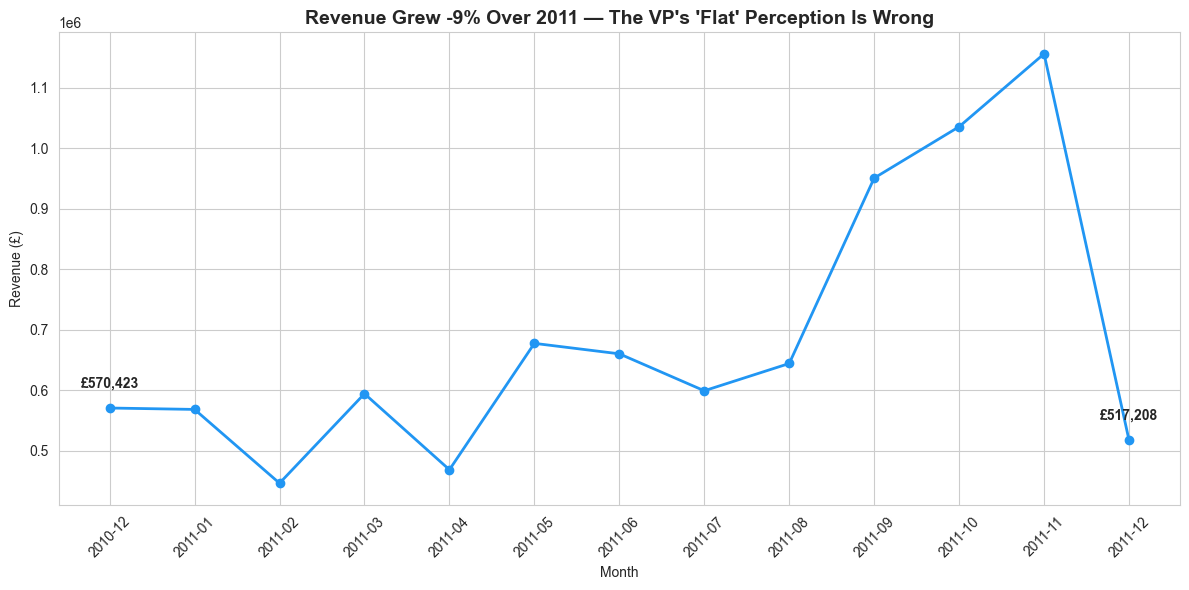

In [3]:
monthly_revenue = (
    df_active.groupby('YearMonth')['Revenue']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_revenue['YearMonth'], monthly_revenue['Revenue'],
        marker='o', color=COLOR_BLUE, linewidth=2)

first_val = monthly_revenue['Revenue'].iloc[0]
last_val = monthly_revenue['Revenue'].iloc[-1]

ax.annotate(f"£{first_val:,.0f}",
            xy=(0, first_val), xytext=(0, 15), textcoords='offset points',
            ha='center', fontweight='bold')
ax.annotate(f"£{last_val:,.0f}",
            xy=(len(monthly_revenue) - 1, last_val), xytext=(0, 15), textcoords='offset points',
            ha='center', fontweight='bold')

pct_growth = (last_val - first_val) / first_val * 100
ax.set_title(
    f"Revenue Grew {pct_growth:.0f}% Over 2011 — The VP's 'Flat' Perception Is Wrong",
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Chart 2 — New vs Returning Customer Revenue

**WHY:** File 2 Query 6 showed revenue growth is increasingly driven by *returning*
customers, while new-customer revenue shrinks. A stacked bar chart shows both trends
on the same scale, month by month.

**HOW** A customer's first-ever purchase month is their `first_purchase_month`. Any
transaction in that month = "New Customer" revenue; everything after = "Returning
Customer" revenue.

**HOW TO VERIFY:** The "Returning Customer" portion of each bar should grow steadily,
while the "New Customer" portion should shrink toward the right side of the chart.


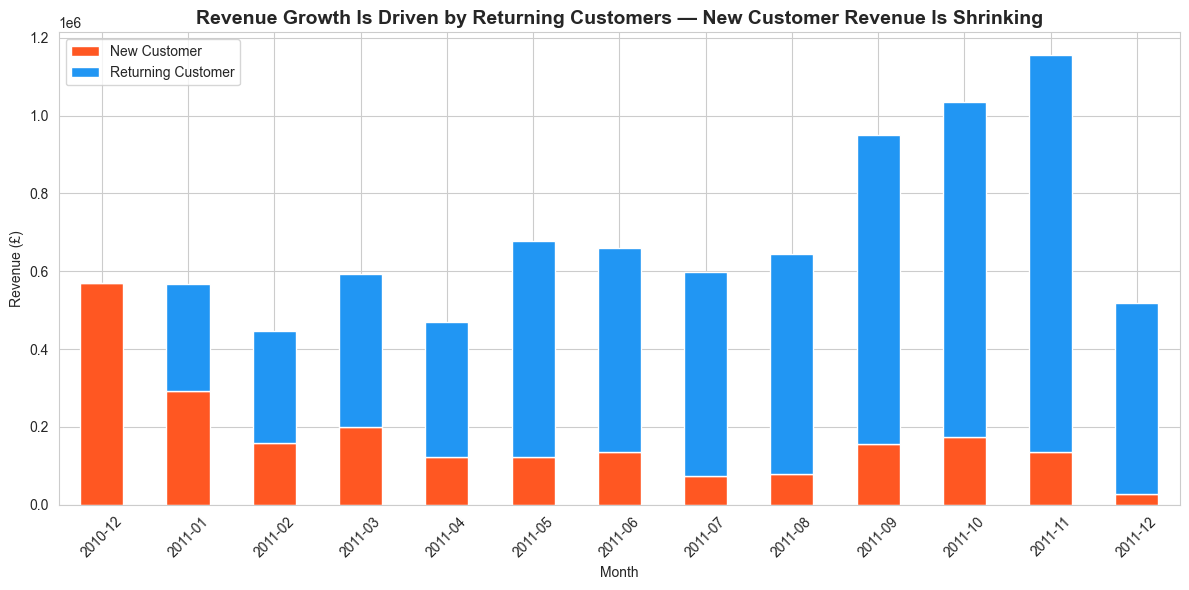

In [4]:
first_purchase = (
    df_active.groupby('CustomerID')['YearMonth']
    .min()
    .reset_index()
    .rename(columns={'YearMonth': 'first_purchase_month'})
)

df_tagged = df_active.merge(first_purchase, on='CustomerID')
df_tagged['customer_type'] = np.where(
    df_tagged['YearMonth'] == df_tagged['first_purchase_month'],
    'New Customer',
    'Returning Customer'
)

revenue_by_type = (
    df_tagged.groupby(['YearMonth', 'customer_type'])['Revenue']
    .sum()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 6))
revenue_by_type.plot(
    kind='bar', stacked=True, ax=ax,
    color=[COLOR_ORANGE, COLOR_BLUE]
)

ax.set_title(
    'Revenue Growth Is Driven by Returning Customers — New Customer Revenue Is Shrinking',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.legend(title='')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Chart 3 — Cohort Retention Heatmap

**WHY:** File 3 (SQL) calculated retention % for every cohort/month combination as a
table. A heatmap turns that table into a picture — darker cells = higher retention.
This is one of the most common charts in DA portfolios because it's so information-dense.

**HOW** Same 4-step logic as `03_customer_cohorts.sql`:
1. Find each customer's `cohort_month` (first purchase month)
2. Tag every transaction with `cohort_index` (months since first purchase)
3. Count active customers per cohort per index
4. Divide by cohort size = retention %

**HOW TO VERIFY:** Column 0 (`cohort_index = 0`) should be 100% for every row — every
customer is "active" in their own first month, by definition.


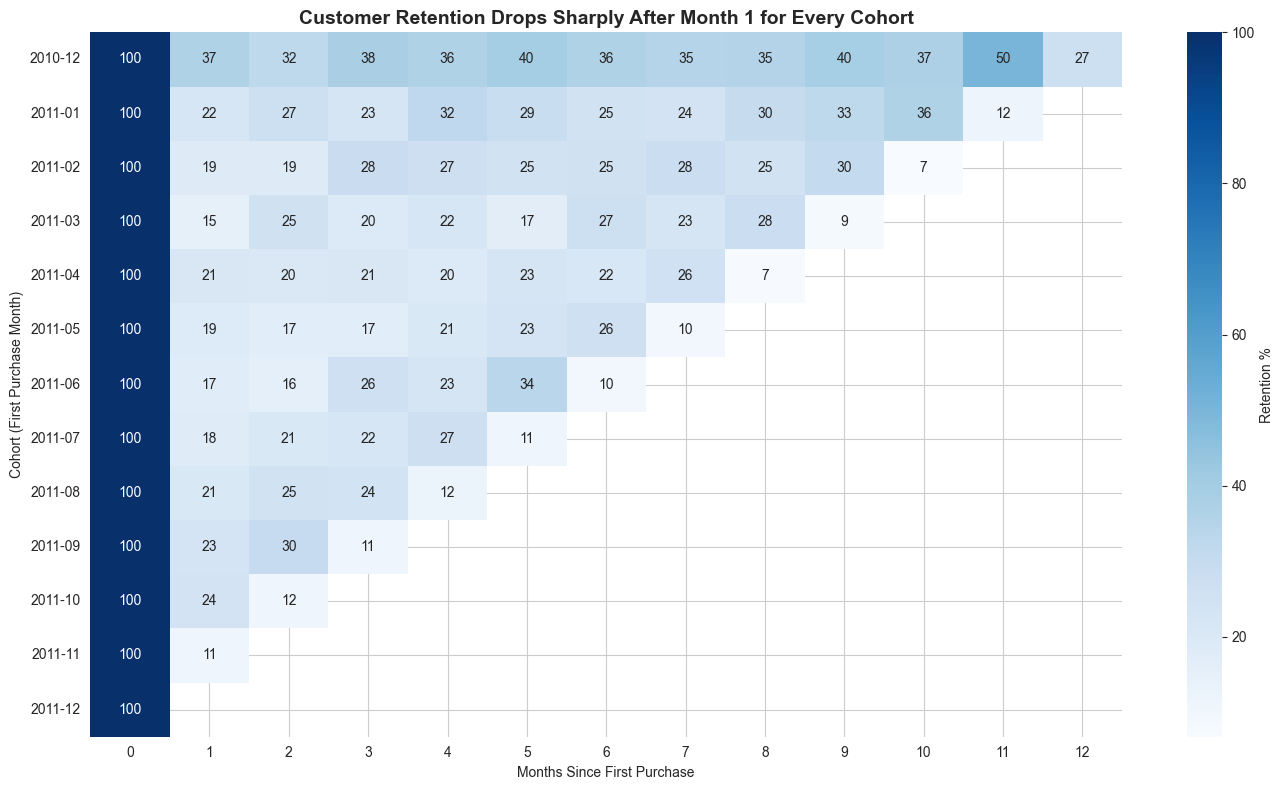

In [5]:
cohort_base = (
    df_active.groupby('CustomerID')['YearMonth']
    .min()
    .reset_index()
    .rename(columns={'YearMonth': 'cohort_month'})
)

df_cohort = df_active.merge(cohort_base, on='CustomerID')

# cohort_index = months between transaction month and cohort month
transaction_dt = pd.to_datetime(df_cohort['YearMonth'], format='%Y-%m')
cohort_dt = pd.to_datetime(df_cohort['cohort_month'], format='%Y-%m')
df_cohort['cohort_index'] = (
    (transaction_dt.dt.year - cohort_dt.dt.year) * 12
    + (transaction_dt.dt.month - cohort_dt.dt.month)
)

cohort_counts = (
    df_cohort.groupby(['cohort_month', 'cohort_index'])['CustomerID']
    .nunique()
    .reset_index(name='active_customers')
)

cohort_sizes = (
    cohort_base.groupby('cohort_month')['CustomerID']
    .nunique()
    .reset_index(name='cohort_size')
)

cohort_data = cohort_counts.merge(cohort_sizes, on='cohort_month')
cohort_data['retention_pct'] = (
    cohort_data['active_customers'] / cohort_data['cohort_size'] * 100
).round(1)

retention_matrix = cohort_data.pivot(
    index='cohort_month', columns='cohort_index', values='retention_pct'
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': 'Retention %'}, ax=ax)

ax.set_title(
    'Customer Retention Drops Sharply After Month 1 for Every Cohort',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.show()

---
## Chart 4 — RFM Segment Revenue Contribution

**WHY:** File 4 (SQL) found Champions = 22.5% of customers but 65.2% of revenue. This
chart shows every segment's revenue contribution side by side, so the concentration is
visually obvious.

**HOW** Same RFM logic as `04_rfm_segmentation.sql`, but using `pd.qcut` instead of
`NTILE(5)`. We use `.rank(method='first')` before `qcut` because many customers share
the exact same `frequency` or `recency_days` value — `qcut` needs unique bin edges.

**HOW TO VERIFY:** "Champions" should be the tallest bar, and the segment order/sizes
should roughly match the Query 4 output from File 4.


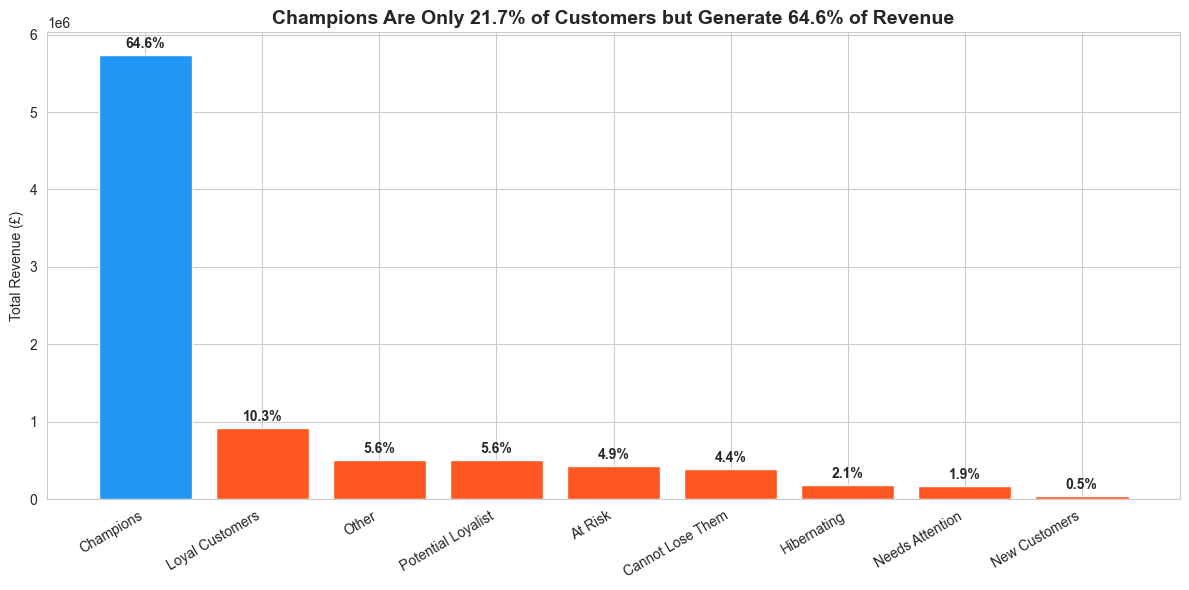

In [6]:
snapshot_date = dt.datetime(2011, 12, 9)
df_active['InvoiceDate_dt'] = pd.to_datetime(df_active['InvoiceDate'])

rfm = df_active.groupby('CustomerID').agg(
    recency_days=('InvoiceDate_dt', lambda x: (snapshot_date - x.max()).days),
    frequency=('InvoiceNo', 'nunique'),
    monetary=('Revenue', 'sum')
).reset_index()

# rank(method='first') breaks ties so qcut can create 5 equal-sized bins
# r_score: smaller recency_days = more recent = better -> labels go 5..1
rfm['r_score'] = pd.qcut(rfm['recency_days'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)
# f_score, m_score: higher = better -> labels go 1..5
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Same segment logic as 04_rfm_segmentation.sql Query 3
conditions = [
    (rfm['r_score'] >= 4) & (rfm['f_score'] >= 4) & (rfm['m_score'] >= 4),
    (rfm['r_score'] >= 3) & (rfm['f_score'] >= 4),
    (rfm['r_score'] >= 4) & (rfm['f_score'].between(2, 3)),
    (rfm['r_score'] >= 4) & (rfm['f_score'] == 1),
    (rfm['r_score'] <= 2) & (rfm['f_score'] >= 4) & (rfm['m_score'] >= 4),
    (rfm['r_score'] <= 2) & (rfm['f_score'] >= 3),
    (rfm['r_score'] == 3) & (rfm['f_score'] <= 2),
    (rfm['r_score'] <= 2) & (rfm['f_score'] <= 2) & (rfm['m_score'] <= 2),
]
choices = [
    'Champions', 'Loyal Customers', 'Potential Loyalist', 'New Customers',
    'Cannot Lose Them', 'At Risk', 'Needs Attention', 'Hibernating'
]
rfm['customer_segment'] = np.select(conditions, choices, default='Other')

segment_revenue = (
    rfm.groupby('customer_segment')['monetary']
    .sum()
    .sort_values(ascending=False)
)
pct_of_revenue = (segment_revenue / segment_revenue.sum() * 100).round(1)

colors = [COLOR_BLUE if seg == 'Champions' else COLOR_ORANGE for seg in segment_revenue.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(segment_revenue.index, segment_revenue.values, color=colors)

for bar, pct in zip(bars, pct_of_revenue.values):
    ax.annotate(f"{pct}%", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points', ha='center', fontweight='bold')

champions_pct = pct_of_revenue['Champions']
champions_cust_pct = (rfm['customer_segment'] == 'Champions').mean() * 100
ax.set_title(
    f"Champions Are Only {champions_cust_pct:.1f}% of Customers but Generate {champions_pct}% of Revenue",
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('')
ax.set_ylabel('Total Revenue (£)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## Chart 5 — Revenue by Day of Week

**WHY:** File 2 (SQL) found ZERO Saturday transactions — confirmed in a follow-up query
across all 13 months. This chart shows the full weekly pattern so the missing Saturday
bar is visually obvious.

**HOW** `reindex(day_order, fill_value=0)` forces all 7 days to appear in the chart, even
though Saturday has no rows in the data at all (without this, Saturday would simply be
missing from the x-axis instead of showing as zero).

**HOW TO VERIFY:** Saturday's bar should be exactly zero. Sunday should also be low
(B2B businesses rarely operate weekends).


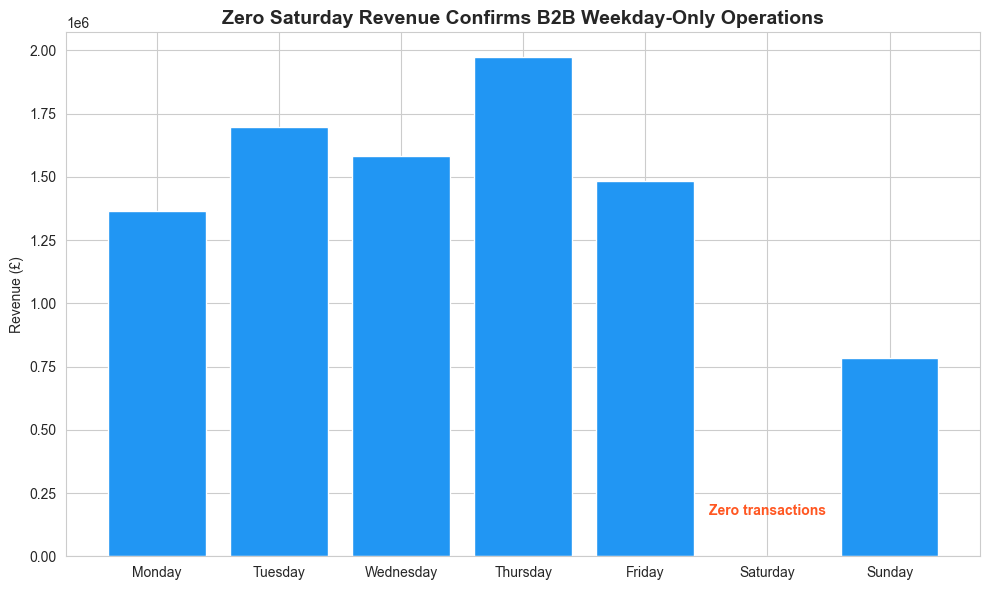

In [7]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

revenue_by_day = (
    df_active.groupby('Day_of_Week')['Revenue']
    .sum()
    .reindex(day_order, fill_value=0)
)

colors = [COLOR_ORANGE if day == 'Saturday' else COLOR_BLUE for day in revenue_by_day.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(revenue_by_day.index, revenue_by_day.values, color=colors)

ax.annotate('Zero transactions', xy=('Saturday', 0), xytext=(0, 30),
             textcoords='offset points', ha='center', fontweight='bold', color=COLOR_ORANGE)

ax.set_title(
    'Zero Saturday Revenue Confirms B2B Weekday-Only Operations',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('')
ax.set_ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

---
## Chart 6 — Revenue by Hour of Day

**WHY:** File 2 Query 5 (SQL) showed revenue by hour. This chart helps the operations
team plan staffing — when do most orders come in?

**HOW TO VERIFY:** Revenue should be near-zero outside business hours (e.g. before 6am
and after 8pm), with a peak somewhere in the late morning / early afternoon.


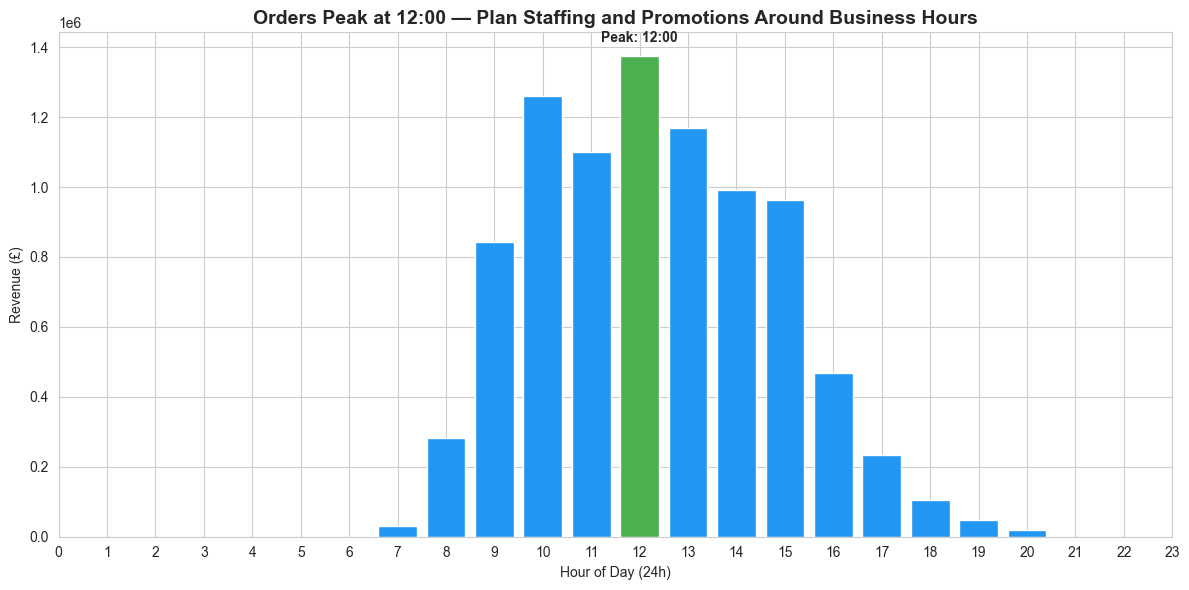

In [8]:
revenue_by_hour = df_active.groupby('Hour')['Revenue'].sum()

peak_hour = revenue_by_hour.idxmax()
colors = [COLOR_GREEN if hour == peak_hour else COLOR_BLUE for hour in revenue_by_hour.index]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(revenue_by_hour.index, revenue_by_hour.values, color=colors)

ax.annotate(f"Peak: {peak_hour}:00", xy=(peak_hour, revenue_by_hour[peak_hour]),
             xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')

ax.set_title(
    f"Orders Peak at {peak_hour}:00 — Plan Staffing and Promotions Around Business Hours",
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('Revenue (£)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

---
## Chart 7 — Top 10 Products by Revenue

**WHY:** File 5 Query 2 (SQL) ranked products after excluding fee/admin codes
(`DOT`, `POST`, `M`, etc.). This chart visualizes the top 10 real products — a horizontal
bar chart works best here because product names are long.

**HOW** `str.match(r'^\d')` keeps only StockCodes that start with a digit — the same
rule used in `regexp_matches(StockCode, '^[0-9]')` in File 5.

**HOW TO VERIFY:** "White Hanging Heart T-Light Holder" and "Regency Cakestand 3 Tier"
should be near the top, matching File 5's results. `DOT`/`POST`/`M` should NOT appear.


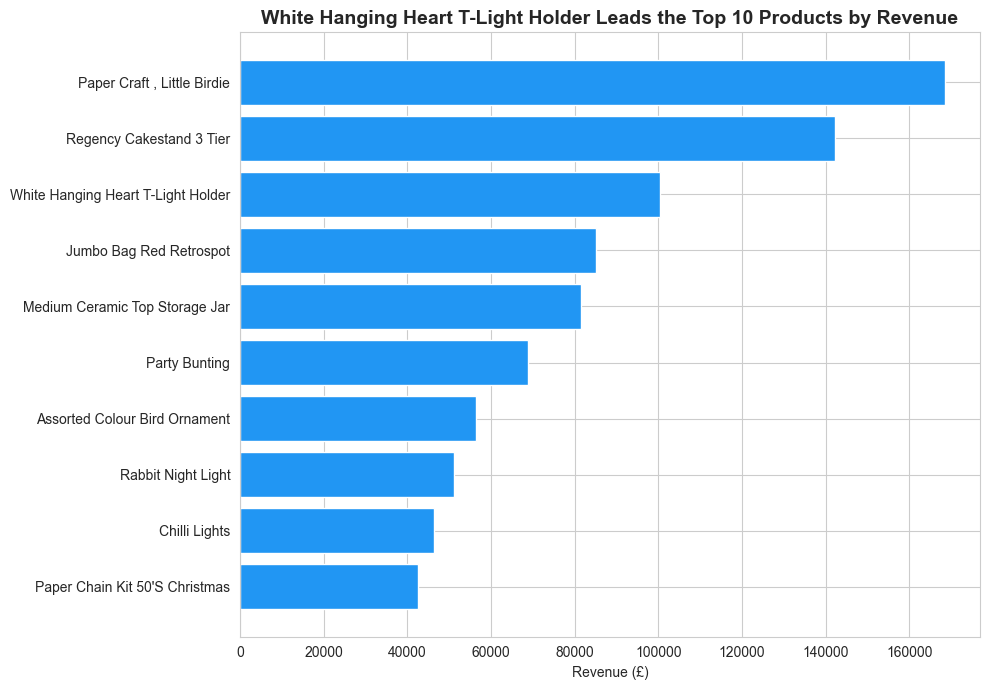

In [9]:
real_products = df_active[df_active['StockCode'].astype(str).str.match(r'^\d')]

top_products = (
    real_products.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()  # ascending so the biggest bar ends up on top in barh
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_products.index, top_products.values, color=COLOR_BLUE)

ax.set_title(
    'White Hanging Heart T-Light Holder Leads the Top 10 Products by Revenue',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Revenue (£)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## Chart 8 — Top 10 Countries by Revenue

**WHY:** File 1 Query 3 and File 5 Query 4 (SQL) showed the UK dominates by volume, but
countries like EIRE and Netherlands have a handful of customers generating outsized
revenue. A log-scale x-axis lets us compare the UK and tiny-but-valuable markets on the
same chart without the UK bar making everything else invisible.

**HOW TO VERIFY:** United Kingdom should be the longest bar by far. EIRE and Netherlands
should still be clearly visible thanks to the log scale, even with only 3 and 9 customers
respectively.


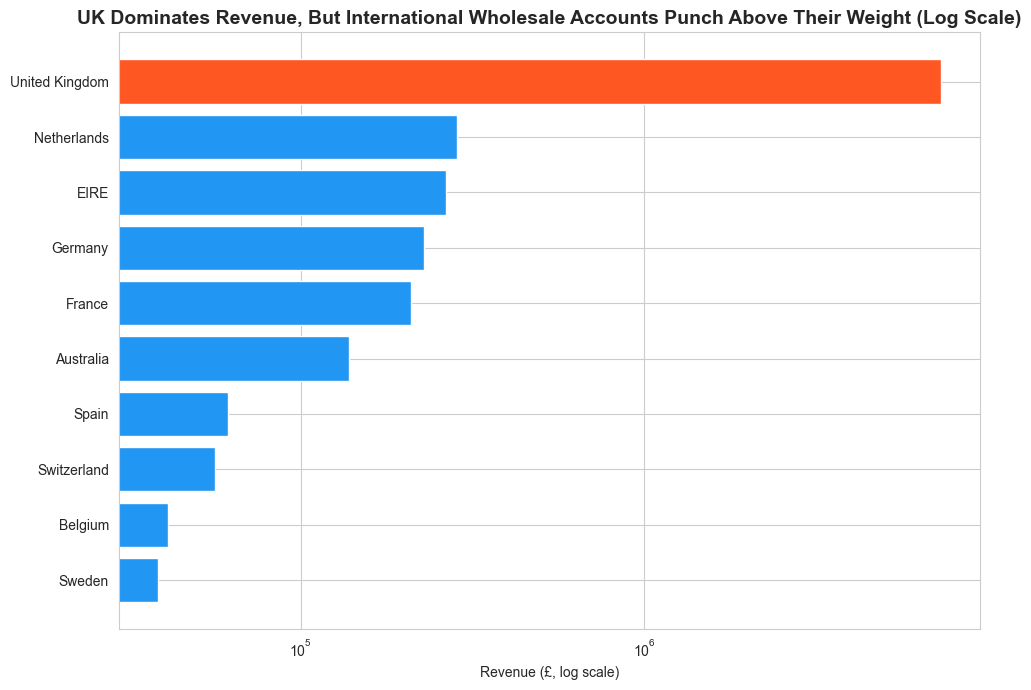

In [10]:
revenue_by_country = (
    df_active.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()  # ascending so UK ends up on top in barh
)

colors = [COLOR_ORANGE if country == 'United Kingdom' else COLOR_BLUE for country in revenue_by_country.index]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(revenue_by_country.index, revenue_by_country.values, color=colors)
ax.set_xscale('log')

ax.set_title(
    'UK Dominates Revenue, But International Wholesale Accounts Punch Above Their Weight (Log Scale)',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Revenue (£, log scale)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## Summary — What Phase 3 Told Us (Visually)

After running all 8 charts you should be able to answer:
- Is revenue actually growing or flat? (Chart 1)
- Is growth coming from new or returning customers? (Chart 2)
- How quickly does retention drop off after a customer's first month? (Chart 3)
- How concentrated is revenue among top customers? (Chart 4)
- Which day is completely dead, and what does that imply about the business model? (Chart 5)
- When during the day should operations/marketing focus? (Chart 6)
- What are the best-selling products? (Chart 7)
- Which countries matter beyond the UK? (Chart 8)

**Next:** Phase 4 — Tableau Dashboard (3 pages), then Phase 5 — Executive Memo
